In [53]:
#Loading Dataset thorugh pandas
import pandas as pd
df=pd.read_csv('Titanic Dataset.csv')
df #print dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.500000,0,0,330911,7.829200,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.000000,1,0,363272,7.000000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.000000,0,0,240276,9.687500,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.000000,0,0,315154,8.662500,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.000000,1,1,3101298,12.287500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
995,1887,1,3,"Lundin, Miss. Olga Elida",female,23.457540,0,0,347469,12.691531,NaN,S
996,1888,0,2,"Gale, Mr. Harry",male,34.822205,1,0,28664,20.380954,NaN,S
997,1889,1,1,"Widener, Mrs. George Dunton (Eleanor Elkins)",female,51.484058,1,1,113503,202.110056,C80,C
998,1890,1,1,"Cornell, Mrs. Robert Clifford (Malvina Helen L...",female,56.753087,2,0,11770,27.050477,C101,S


In [54]:
#checking null values
df.isnull().sum() 
#Age cabin and fare olumn contain null values


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            196
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          783
Embarked         0
dtype: int64

In [66]:
# to fill data,we chck skewness through descriptive statistics then fill accordingly thourgh median/mean/mode
df.describe()
#Age and dare both have median<mean ,,which shows it has skewness fill them with median
df['Age']=df['Age'].fillna('median')
df['Fare']=df['Fare'].fillna('median')
#checking null values
df=df.drop('Cabin',axis=1) #No need here
df.columns
print(df.isnull().sum()) # null values are filed


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


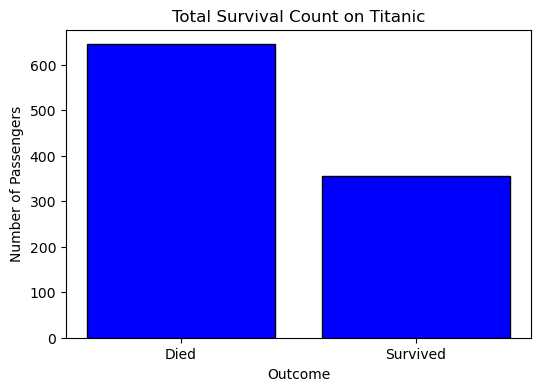

In [56]:
#Creating visualizations
import matplotlib.pyplot as plt
df
#(1)Survival Count 
plt.figure(figsize=(6,4))
survived_class=df['Survived'].value_counts()
plt.bar(['Died','Survived'],survived_class,color='blue',edgecolor='black')
plt.xlabel('Outcome')
plt.ylabel('Number of Passengers')
plt.title('Total Survival Count on Titanic')
plt.show()

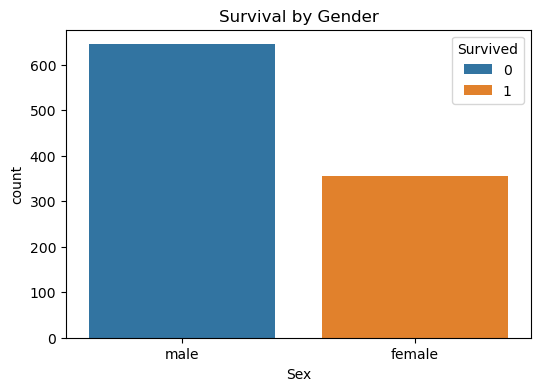

In [57]:
#Survival by Gender
plt.figure(figsize=(6,4))
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='Sex',hue='Survived',data=df)
plt.title('Survival by Gender')
plt.show()

float64


Text(0.5, 1.0, 'Age Distribution')

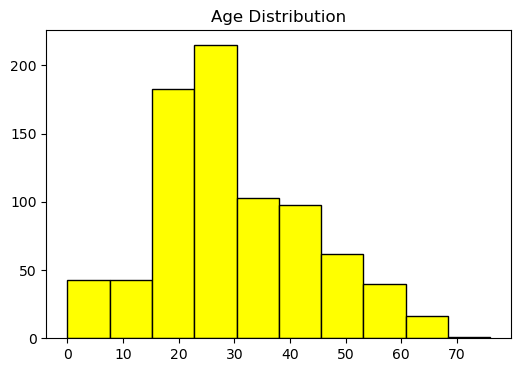

In [58]:
#changing datatype tonfloat instead of object
plt.figure(figsize=(6,4))
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
print(df['Age'].dtype)
#Age Distribution
plt.hist(df['Age'],bins=10,color='yellow',edgecolor='black')
plt.title('Age Distribution')


C:\Users\arooj\AppData\Local\Temp\ipykernel_20488\4021970574.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([fare_1, fare_2, fare_3], labels=['1st', '2nd', '3rd'])


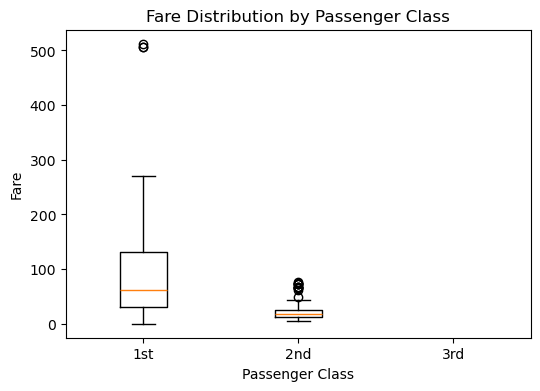

In [59]:
df['Fare'] = pd.to_numeric(df['Fare'], errors='coerce')
#Fare by gender
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
fare_1 = df[df['Pclass'] == 1]['Fare']
fare_2 = df[df['Pclass'] == 2]['Fare']
fare_3 = df[df['Pclass'] == 3]['Fare']

plt.boxplot([fare_1, fare_2, fare_3], labels=['1st', '2nd', '3rd'])
plt.title("Fare Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.show()

          Survived    Pclass       Age     SibSp     Parch      Fare
Survived  1.000000 -0.085592 -0.032571  0.125483  0.188386  0.219430
Pclass   -0.085592  1.000000 -0.498016 -0.011479  0.039752 -0.561642
Age      -0.032571 -0.498016  1.000000 -0.094183 -0.037613  0.315188
SibSp     0.125483 -0.011479 -0.094183  1.000000  0.297867  0.179530
Parch     0.188386  0.039752 -0.037613  0.297867  1.000000  0.237543
Fare      0.219430 -0.561642  0.315188  0.179530  0.237543  1.000000


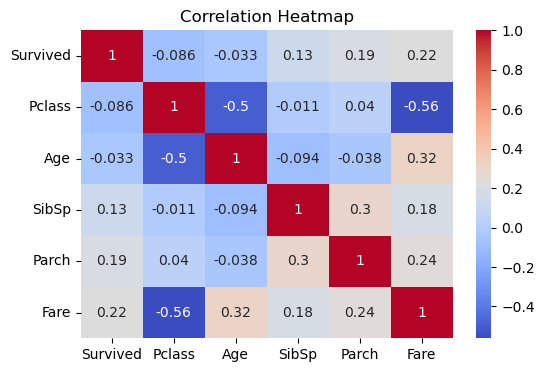

In [60]:
#Correlation Analysis
#shows how strongly numeric features are related,,so first separate out numeric features
numeric_cols=df[['Survived','Pclass','Age','SibSp','Parch','Fare']]
#calculate correlation matrix
corr_matrix = numeric_cols.corr()
print(corr_matrix)
#much better to visualize it through Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [69]:
#Question 01
#Identify the three most influential featuresaffecting the target variable. Support your conclusion with statistical evidence and visualizations.
#select relevant numeric columns
# Convert numeric columns safely
numeric_cols = df[['Survived','Pclass','Age','SibSp','Parch','Fare']].copy()
# Convert columns to numeric
for col in numeric_cols.columns:
    numeric_cols[col] = pd.to_numeric(numeric_cols[col], errors='coerce')
# Fill missing values again
numeric_cols['Age'] = numeric_cols['Age'].fillna(numeric_cols['Age'].median())
numeric_cols['Fare'] = numeric_cols['Fare'].fillna(numeric_cols['Fare'].median())
# Now calculate correlation
corr_matrix = numeric_cols.corr()
print(corr_matrix)
#Find the Correlation with the Target Variable(survived)
corr_with_target = corr_matrix['Survived']
print('Correlation of each feature with target variable(survived):\n',corr_with_target)
#sort correlation to easily identify values
corr_with_target = corr_matrix['Survived'].sort_values(ascending=False)
print('Sorted values:\n',corr_with_target)
#Take absolute values(instead of -ve that is just due to direction) and sort again to get top strongly related features
corr_abs = corr_with_target.abs()
print("Absolute Correlation Values:\n")
print(corr_abs)
corr_abs = corr_abs.sort_values(ascending=False)
print(corr_abs)
#Also remove survived(target col)As we dont have to find relation with itself
corr_abs = corr_abs.drop('Survived')
print('Target var removed:\n',corr_abs)
#Extract top 3 features now
print('Top 3  most influential features affecting the target variable are:\n',corr_abs.head(3))

          Survived    Pclass       Age     SibSp     Parch      Fare
Survived  1.000000 -0.085592 -0.024464  0.125483  0.188386  0.219623
Pclass   -0.085592  1.000000 -0.475788 -0.011479  0.039752 -0.561708
Age      -0.024464 -0.475788  1.000000 -0.074860 -0.027861  0.319693
SibSp     0.125483 -0.011479 -0.074860  1.000000  0.297867  0.179679
Parch     0.188386  0.039752 -0.027861  0.297867  1.000000  0.237653
Fare      0.219623 -0.561708  0.319693  0.179679  0.237653  1.000000
Correlation of each feature with target variable(survived):
 Survived    1.000000
Pclass     -0.085592
Age        -0.024464
SibSp       0.125483
Parch       0.188386
Fare        0.219623
Name: Survived, dtype: float64
Sorted values:
 Survived    1.000000
Fare        0.219623
Parch       0.188386
SibSp       0.125483
Age        -0.024464
Pclass     -0.085592
Name: Survived, dtype: float64
Absolute Correlation Values:

Survived    1.000000
Fare        0.219623
Parch       0.188386
SibSp       0.125483
Age         

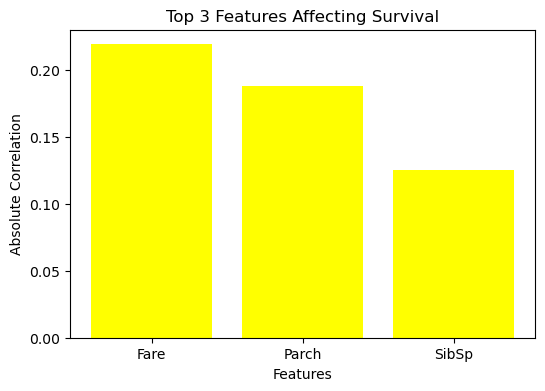

In [63]:
#visualization of top 3 features
top3 = corr_abs.head(3)
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.bar(top3.index, top3.values,color='yellow')
plt.title("Top 3 Features Affecting Survival")
plt.xlabel("Features")
plt.ylabel("Absolute Correlation")
plt.show()

In [ ]:
# QUESTION # 02
#ANSWER:
'''If the dataset gets really big like from 1,000 rows to 10 million rows the dataset will be hard to work with. The 
dataset will use a lot of memory take a time to process and be difficult to visualize.If I load the dataset into Pandas 
it will use up all my available RAM and slow down my computer.To work with the dataset I will process the dataset in 
chunks. I can also use tools like Dask or PySpark to help with this.I will store the dataset in a format that uses less 
space. When I want to look at the dataset I will use a sample of the dataset for visualization.. When I do analysis I
will use the full dataset.This new way of working with the dataset will make it easier to handle datasets, like this one.
It will be faster. Use less memory so the dataset will be easier to work with.'''